In [1]:
import pandas as pd

import plotly.express as px

In [2]:
%run helpers.ipynb

In [3]:
oscar_with_imdb, imdb_non_oscar = read_data('oscar_with_imdb.csv', 'imdb_non_oscar.csv')

oscar_with_imdb['Status'] = oscar_with_imdb['Winner'].apply(lambda row: 'Winner' if row == True else 'Nominated')
imdb_non_oscar['Status'] = 'No nomination'

In [4]:
columns = ['title', 'rating', 'meta_score', 'votes', 'Status']
oscar_df = oscar_with_imdb[columns]
imdb_df = imdb_non_oscar[columns]

rating_graph_df = pd.concat([oscar_df, imdb_df], axis=0)

rating_graph_df

,title,rating,meta_score,votes,Status
0,The Noose,6.5,NaN,93.0,Nominated
1,The Patent Leather Kid,6.0,NaN,623.0,Nominated
2,The Last Command,7.9,NaN,4800.0,Winner
3,The Way of All Flesh,6.6,NaN,241.0,Winner
4,A Ship Comes In,5.5,NaN,246.0,Nominated
...,...,...,...,...,...
55679,The Toxic Avenger,6.0,66.0,554.0,No nomination
55680,The Astronaut,6.0,NaN,33.0,No nomination
55681,Popeye: The Slayer Man,3.8,NaN,425.0,No nomination
55682,Night of the Dead Sorority Babes,3.0,NaN,73.0,No nomination


In [5]:
# bin the imdb ratings
bins = list(range(1, 11))
rating_graph_df['rating_bin'] = pd.cut(
    rating_graph_df['rating'],
    bins=bins,
    labels=range(1, 10),
    right=False, # bins should be [1, 2) (i.e rating 1 to 1.9)
    include_lowest=True # values like 1.0 won't be excluded
)

# group by counts for each imdb rating bin's oscar status
# add average user votes and metacritic score for each bin
rating_bin_counts = (
    rating_graph_df
    .groupby(['rating_bin', 'Status'])
    .agg(
        count=('votes', 'sum'),
        avg_votes=('votes', lambda x: round(x.mean(), 0)), # round to nearest whole number
        avg_meta_score=('meta_score', lambda x: round(x.mean(), 1)) # round to one decimal place
    )
    .reset_index()
)

In [6]:
rating_bin_counts

,rating_bin,Status,count,avg_votes,avg_meta_score
0,1,No nomination,692094.0,10178.0,30.6
1,2,No nomination,1580219.0,4329.0,20.6
2,3,No nomination,4738243.0,2910.0,26.8
3,3,Nominated,1002.0,501.0,NaN
4,4,No nomination,17837217.0,3223.0,34.4
5,4,Nominated,580001.0,23200.0,36.0
6,4,Winner,866.0,866.0,NaN
7,5,No nomination,94641691.0,6614.0,44.7
8,5,Nominated,4378847.0,13032.0,55.7
9,5,Winner,1258870.0,48418.0,63.7


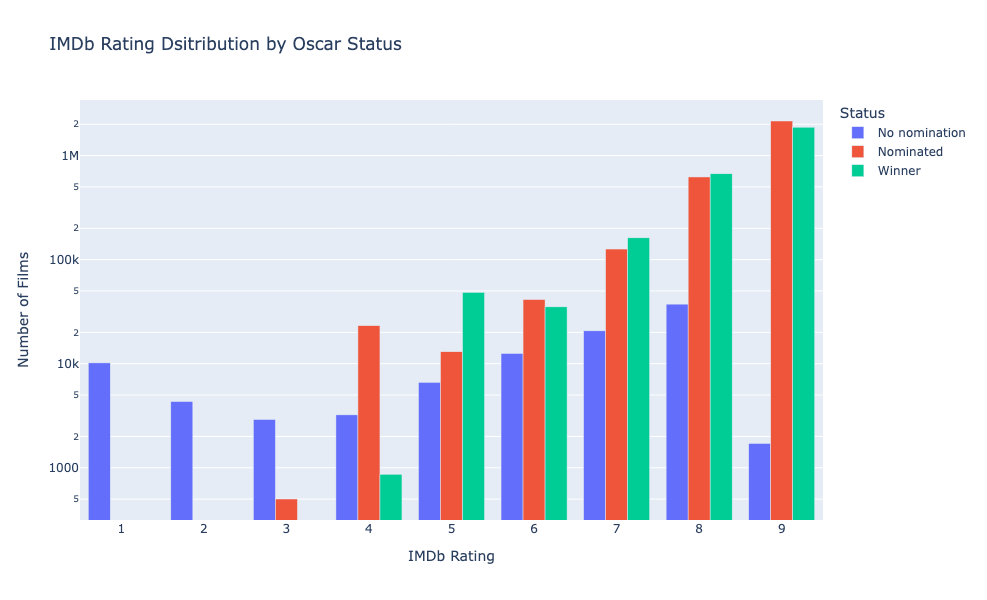

In [7]:
fig = px.bar(
    rating_bin_counts,
    x='rating_bin',
    y='avg_votes',
    color='Status',
    barmode='group',
    title='IMDb Rating Dsitribution by Oscar Status',
    hover_data={
        'rating_bin': False,
        'Status': False,
        'count': ':,',
        'avg_votes': ':,',
        'avg_meta_score': True
    },
    labels={
        'count': 'Film Count',
        'avg_votes': 'Average User Votes',
        'avg_meta_score': 'Average Metacritic Score'
    }
)

fig.update_layout(
    xaxis_title='IMDb Rating',
    yaxis_title='Number of Films',
    height=600,
    width=1000
)

fig.update_layout(yaxis_type='log')

fig.show()

A number of interesting insights can be seen from the chart. For example, each category of films by their Oscar status shows a uniform distribution relative to their respective IMDb rating range. Filtering out each status on the legend will show the following:
- Films that received **no Oscar nominations** most typically average a user rating of `6/10`, before qucikly tailing off near the higher ratings of `8/10` and `9/10`.

- **Oscar nominated** films were found to show the same trend, but instead had most films averaging a user rating of `7/10`. These films having award prestige would suggest that audiences would find them to be of higher qualitty than non-nominated films. Additionally, while non-nomiated films had at least one film in every IMDb rating category, Oscar nominated films lowest IMDb ratings started at `3/10`.

- **Oscar winning** films showed the same trends as Oscar nominees,  however, these films lowest IMDb ratings started at `4/10`.


Another interesting insight is comparing IMDb user interest against critical acclaim, rather than just award prestige. For each film's Oscar status, comparing these categories' average Metacritic score vs IMDb rating yielded the following:
- For **non-nominated** films, users were found to be a lot harsher than critics for films they scored a `1/10`. The average Metacritic score for these films was instead around **30.6/100**. Users that rated non-nominated films as `2/10` were in line with the Metacritic ratings, as they scored an average of **20.6/100**. The rest of the Metacritic averages showed differences that were either at or below the IMDb user rating range:

    - The average Metacritic rating for non-nominated films that IMDb users scored as `3/10` was **26.8/100**.
    - The average Metacritic rating for non-nominated films that IMDb users scored as `4/10` was **34.4/100**.
    - The average Metacritic rating for non-nominated films that IMDb users scored as `5/10` was **44.7/100**.
    - The average Metacritic rating for non-nominated films that IMDb users scored as `6/10` was **57.9/100**.
    - The average Metacritic rating for non-nominated films that IMDb users scored as `7/10` was **69.7/100**.
    - The average Metacritic rating for non-nominated films that IMDb users scored as `8/10` was **77.8/100**.
    
The biggest difference in average Metacritic ratings was for non-nominated films that IMDb users scored as `9/10`. Critics rated these films a score of **61.5/100** on average. However, it is important to point out that the number of non-nominated films that IMDb users scored as `9/10` is quite low relative to others. There are only 66 films in that fall into this category in this dataset and the average user vote count for these films are around 1,700.

For **Oscar nominees and winners**, average Metacritic ratings appear to score at or above IMDb user ratings for all ranges.